# Seasonal Agriculture Performance Analysis

This project focuses on analyzing agricultural data from different seasons.

The dataset contains information about crops, farms, environmental conditions,
resource usage, production, yield, water usage and economic performance.

The main aim is to compare agricultural performance across seasons and find
useful patterns and relationships in the data.

## 1. Importing Required Libraries

First, we import the Python libraries required for this project.

Pandas is used for handling the dataset, NumPy is used for numerical operations,
Matplotlib and Seaborn are used for creating graphs, and SciPy is used for
statistical analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

print("Libraries imported successfully")

Libraries imported successfully


## 2. Loading the Dataset

The dataset is stored in a CSV file. We use Pandas to read the file and store
the data in a DataFrame called `df`.

In [4]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


## 3. Initial Dataset Exploration

Before starting the analysis, we first look at the data to understand
what the dataset contains.

### First Five Rows

The `head()` function displays the first five rows of the dataset.
This helps us get a basic idea about the values in different columns.

In [5]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [7]:
for column in df.columns:
    print(column)

Farm_ID
State
District
Crop
Season
Farm_Area_Hectares
Rainfall_mm
Avg_Temperature_C
Humidity_pct
Sunlight_Hours_Day
Soil_pH
Soil_Moisture_pct
Nitrogen_kg_ha
Phosphorus_kg_ha
Potassium_kg_ha
Irrigation_Method
Fertilizer_kg_ha
Pesticide_Litre_ha
Seed_Quality_Score
Yield_Tonnes_Ha
Production_Tonnes
Market_Price_INR_Tonne
Total_Cost_INR
Revenue_INR
Profit_INR
Water_Used_m3
Water_Efficiency_t_per_1000m3
Disease_Pest_Risk_pct


### Last Five Rows

The `tail()` function displays the last five rows of the dataset.

In [8]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


### Dataset Information

The `info()` function is used to check the data types of the columns
and the number of non-null values present in each column.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

### Statistical Summary

The `describe()` function gives some basic statistical information
about the numerical columns, such as mean, minimum, maximum and
standard deviation.

In [10]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 5. Data Cleaning

Before performing the analysis, the dataset needs to be checked for
missing values, duplicate rows and unnecessary spaces in text values.

In [11]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

### Checking Missing Values

First, we check whether any values are missing from the dataset.
Missing values can affect the results of the analysis.

In [ ]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
df["State"] = df["State"].str.strip()
df["District"] = df["District"].str.strip()
df["Crop"] = df["Crop"].str.strip()
df["Season"] = df["Season"].str.strip()
df["Irrigation_Method"] = df["Irrigation_Method"].str.strip()

In [15]:
print("Seasons:")
print(df["Season"].unique())

Seasons:
['Kharif' 'Rabi' 'Zaid']


In [16]:
print("Crops:")
print(df["Crop"].unique())

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']


In [17]:
print("Irrigation Methods:")
print(df["Irrigation_Method"].unique())

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


### Columns Having Missing Values

Here we display only the columns that contain missing values.
This makes it easier to identify where cleaning may be required.

In [18]:
df.isnull().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

### Handling Missing Values

If missing values are present, they are filled using the mode for
categorical columns and the median for numerical columns.

The median is used for numerical values because it is less affected
by unusually high or low values.

In [19]:
df["State"] = df["State"].fillna(df["State"].mode()[0])
df["District"] = df["District"].fillna(df["District"].mode()[0])
df["Crop"] = df["Crop"].fillna(df["Crop"].mode()[0])
df["Season"] = df["Season"].fillna(df["Season"].mode()[0])
df["Irrigation_Method"] = df["Irrigation_Method"].fillna(df["Irrigation_Method"].mode()[0])

In [20]:
df["Farm_Area_Hectares"] = df["Farm_Area_Hectares"].fillna(df["Farm_Area_Hectares"].median())
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Avg_Temperature_C"] = df["Avg_Temperature_C"].fillna(df["Avg_Temperature_C"].median())
df["Humidity_pct"] = df["Humidity_pct"].fillna(df["Humidity_pct"].median())
df["Sunlight_Hours_Day"] = df["Sunlight_Hours_Day"].fillna(df["Sunlight_Hours_Day"].median())
df["Soil_pH"] = df["Soil_pH"].fillna(df["Soil_pH"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())

df["Nitrogen_kg_ha"] = df["Nitrogen_kg_ha"].fillna(df["Nitrogen_kg_ha"].median())
df["Phosphorus_kg_ha"] = df["Phosphorus_kg_ha"].fillna(df["Phosphorus_kg_ha"].median())
df["Potassium_kg_ha"] = df["Potassium_kg_ha"].fillna(df["Potassium_kg_ha"].median())

df["Fertilizer_kg_ha"] = df["Fertilizer_kg_ha"].fillna(df["Fertilizer_kg_ha"].median())
df["Pesticide_Litre_ha"] = df["Pesticide_Litre_ha"].fillna(df["Pesticide_Litre_ha"].median())
df["Seed_Quality_Score"] = df["Seed_Quality_Score"].fillna(df["Seed_Quality_Score"].median())

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())
df["Production_Tonnes"] = df["Production_Tonnes"].fillna(df["Production_Tonnes"].median())

df["Market_Price_INR_Tonne"] = df["Market_Price_INR_Tonne"].fillna(df["Market_Price_INR_Tonne"].median())
df["Total_Cost_INR"] = df["Total_Cost_INR"].fillna(df["Total_Cost_INR"].median())
df["Revenue_INR"] = df["Revenue_INR"].fillna(df["Revenue_INR"].median())
df["Profit_INR"] = df["Profit_INR"].fillna(df["Profit_INR"].median())

df["Water_Used_m3"] = df["Water_Used_m3"].fillna(df["Water_Used_m3"].median())
df["Water_Efficiency_t_per_1000m3"] = df["Water_Efficiency_t_per_1000m3"].fillna(df["Water_Efficiency_t_per_1000m3"].median())

df["Disease_Pest_Risk_pct"] = df["Disease_Pest_Risk_pct"].fillna(df["Disease_Pest_Risk_pct"].median())

In [21]:
df.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

### Checking Seasons

We check the different seasons available in the dataset.

In [22]:
print(df["Season"].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


### Season Distribution Graph

The following graph shows the number of agricultural records available
for each season.

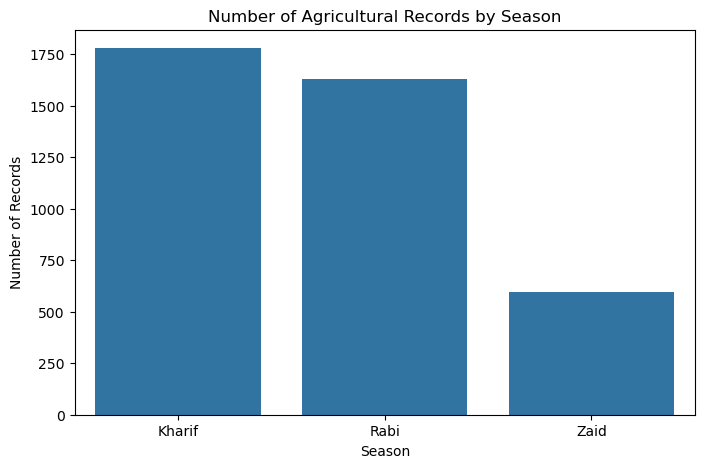

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Season")

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.show()

### Checking Crops

We check which different crops are present in the dataset.

In [24]:
print(df["Crop"].value_counts())

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


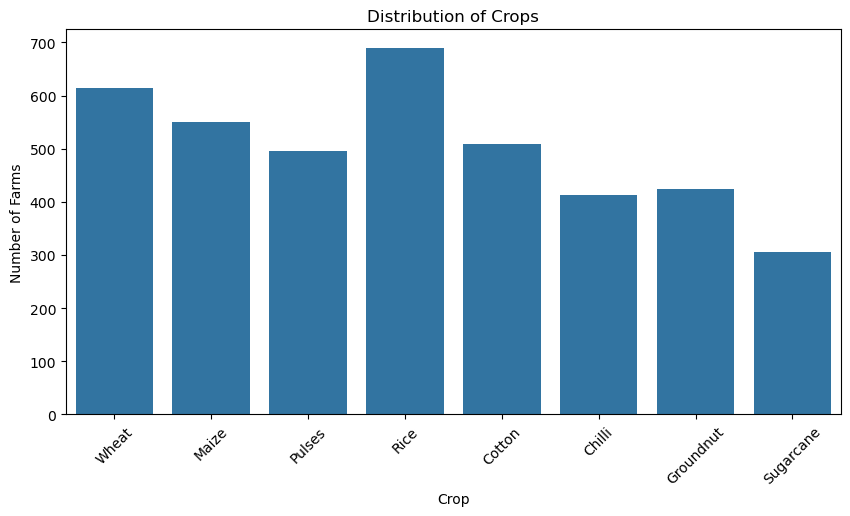

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Crop")

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")

plt.xticks(rotation=45)

plt.show()

## 7. Environmental Conditions

### Average Rainfall Across Seasons

Rainfall can have an important effect on agricultural activities.
Here, we calculate and compare the average rainfall for each season.

In [26]:
rainfall = df.groupby("Season")["Rainfall_mm"].mean()

print(rainfall)

Season
Kharif    849.199663
Rabi      437.615366
Zaid      304.654714
Name: Rainfall_mm, dtype: float64


### Rainfall Comparison

The graph shows the average rainfall recorded in each season.

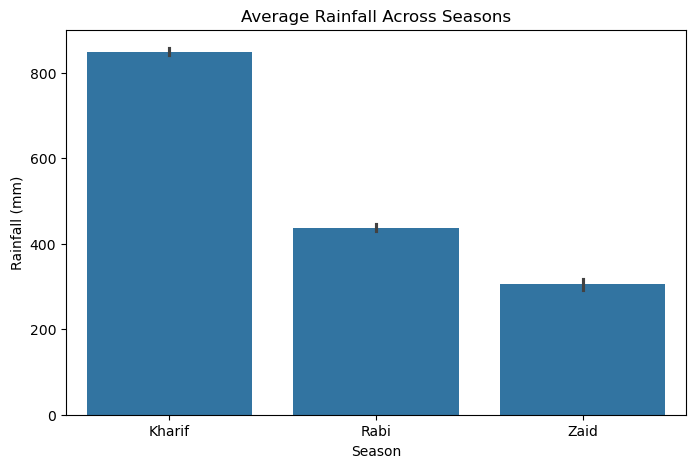

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Rainfall_mm")

plt.title("Average Rainfall Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

### Average Temperature Across Seasons

Temperature is another environmental factor that can affect crop growth.
Here, we compare the average temperature across different seasons.

In [28]:
temperature = df.groupby("Season")["Avg_Temperature_C"].mean()

print(temperature)

Season
Kharif    28.454019
Rabi      23.489183
Zaid      31.042088
Name: Avg_Temperature_C, dtype: float64


### Temperature Comparison

The graph shows how average temperature differs between seasons.

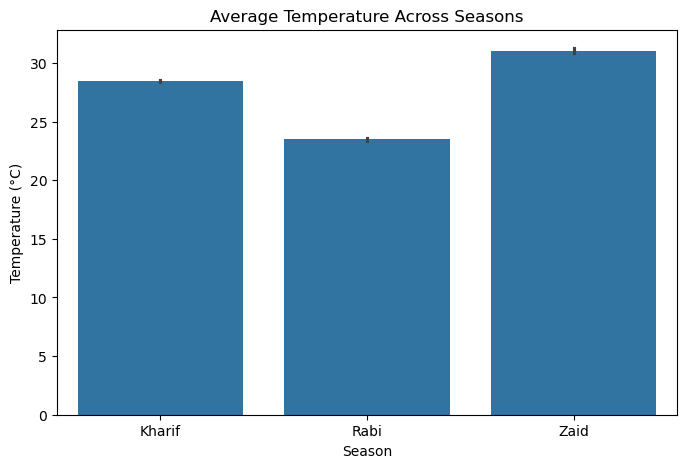

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Avg_Temperature_C")

plt.title("Average Temperature Across Seasons")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")

plt.show()

### Average Humidity Across Seasons

Humidity can affect crop growth as well as the possibility of
disease and pest problems.

Here, we compare the average humidity for different seasons.

In [30]:
humidity = df.groupby("Season")["Humidity_pct"].mean()

print(humidity)

Season
Kharif    71.812591
Rabi      57.893178
Zaid      52.012121
Name: Humidity_pct, dtype: float64


### Humidity Comparison

The graph shows the average humidity recorded in each season.

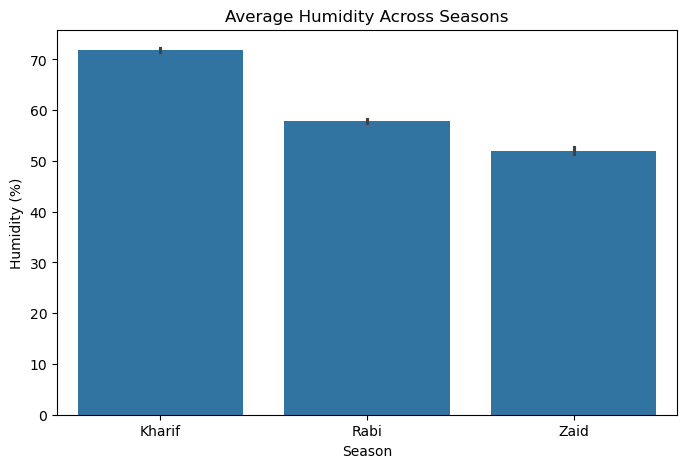

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Humidity_pct")

plt.title("Average Humidity Across Seasons")
plt.xlabel("Season")
plt.ylabel("Humidity (%)")

plt.show()

### Average Sunlight Hours Across Seasons

Sunlight is an important factor for crop growth.
Here, we compare the average number of sunlight hours per day
across seasons.

In [32]:
sunlight = df.groupby("Season")["Sunlight_Hours_Day"].mean()

print(sunlight)

Season
Kharif    6.793367
Rabi      7.589797
Zaid      8.178788
Name: Sunlight_Hours_Day, dtype: float64


### Sunlight Comparison

The graph shows the average sunlight hours for each season.

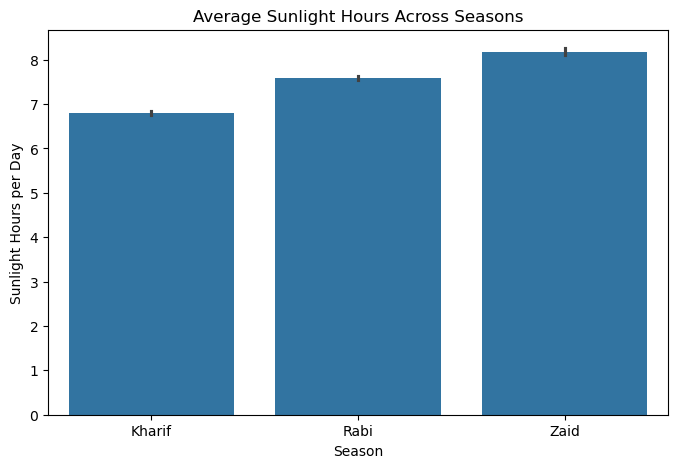

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Sunlight_Hours_Day")

plt.title("Average Sunlight Hours Across Seasons")
plt.xlabel("Season")
plt.ylabel("Sunlight Hours per Day")

plt.show()

### Average Soil Moisture Across Seasons

Soil moisture indicates the amount of water available in the soil.
Here, we compare the average soil moisture percentage across seasons.

In [34]:
soil_moisture = df.groupby("Season")["Soil_Moisture_pct"].mean()

print(soil_moisture)

Season
Kharif    31.149859
Rabi      24.069392
Zaid      19.279630
Name: Soil_Moisture_pct, dtype: float64


### Soil Moisture Comparison

The graph shows the difference in average soil moisture between seasons.

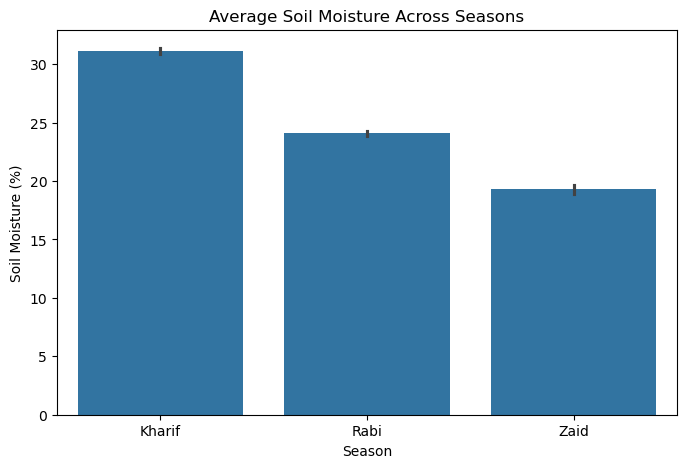

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Soil_Moisture_pct")

plt.title("Average Soil Moisture Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.show()

### Average Soil pH Across Seasons

Soil pH is related to soil conditions and can affect the availability
of nutrients to crops.

Here, we compare the average soil pH across different seasons.

In [36]:
soil_ph = df.groupby("Season")["Soil_pH"].mean()

print(soil_ph)

Season
Kharif    6.727993
Rabi      6.673749
Zaid      6.694865
Name: Soil_pH, dtype: float64


In [ ]:
### Soil pH Comparison

The graph shows the average soil pH recorded in each season.

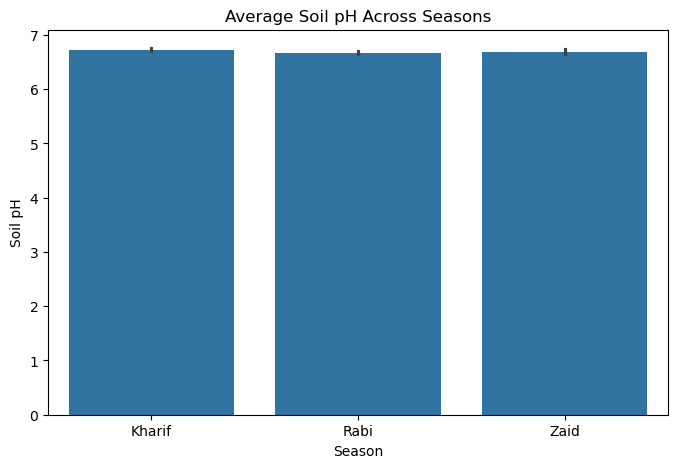

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Soil_pH")

plt.title("Average Soil pH Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil pH")

plt.show()

## 8. Nutrient and Fertilizer Analysis

Plants require nutrients such as nitrogen, phosphorus and potassium
for healthy growth.

In this section, we compare nutrient usage across different seasons.

### Average Nitrogen, Phosphorus and Potassium

The following table shows the average amount of nitrogen, phosphorus
and potassium used per hectare in each season.

In [38]:
nutrients = df.groupby("Season")[
    ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"]
].mean()

print(nutrients)

        Nitrogen_kg_ha  Phosphorus_kg_ha  Potassium_kg_ha
Season                                                   
Kharif      120.020124         58.096515       105.303485
Rabi        120.402827         57.311002       103.926060
Zaid        120.525421         58.129125       105.416835


### Nutrient Usage Across Seasons

The graph compares the average nitrogen, phosphorus and potassium
usage across different seasons.

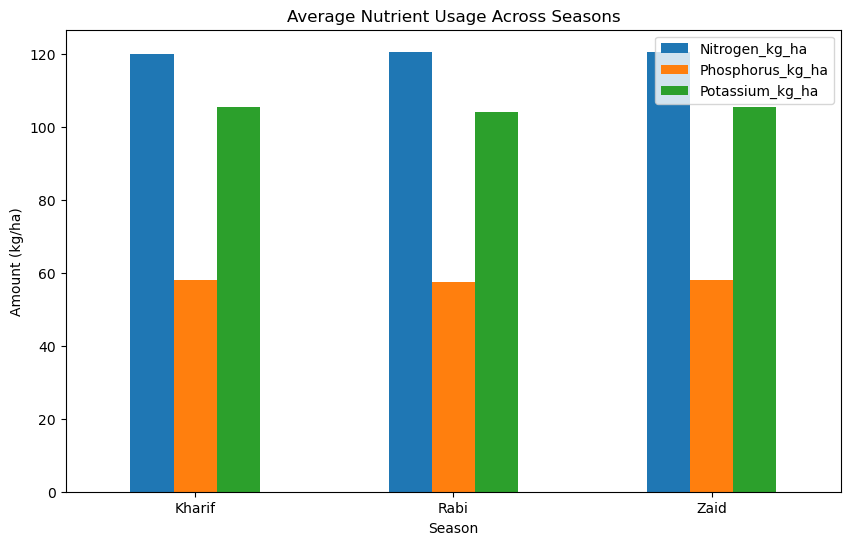

In [39]:
nutrients.plot(kind="bar", figsize=(10,6))

plt.title("Average Nutrient Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (kg/ha)")

plt.xticks(rotation=0)

plt.show()

### Average Fertilizer Usage

Fertilizer usage can influence crop growth and yield.
Here, we compare the average fertilizer usage across seasons.

In [40]:
fertilizer = df.groupby("Season")["Fertilizer_kg_ha"].mean()

print(fertilizer)

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


### Fertilizer Usage Comparison

The graph shows the average fertilizer used per hectare in each season.

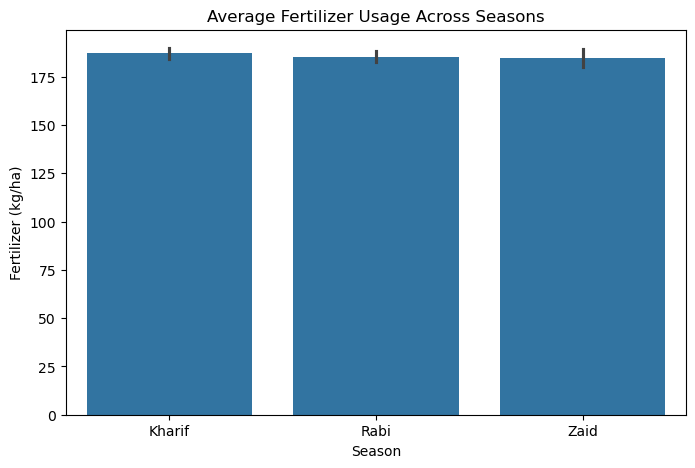

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Fertilizer_kg_ha")

plt.title("Average Fertilizer Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")

plt.show()

### Average Pesticide Usage

Pesticides are used to control pests and diseases.
Here, we compare pesticide usage across different seasons.

In [42]:
pesticide = df.groupby("Season")["Pesticide_Litre_ha"].mean()

print(pesticide)

Season
Kharif    5.079747
Rabi      5.024690
Zaid      5.171212
Name: Pesticide_Litre_ha, dtype: float64


### Pesticide Usage Comparison

The graph shows the average pesticide usage for each season.

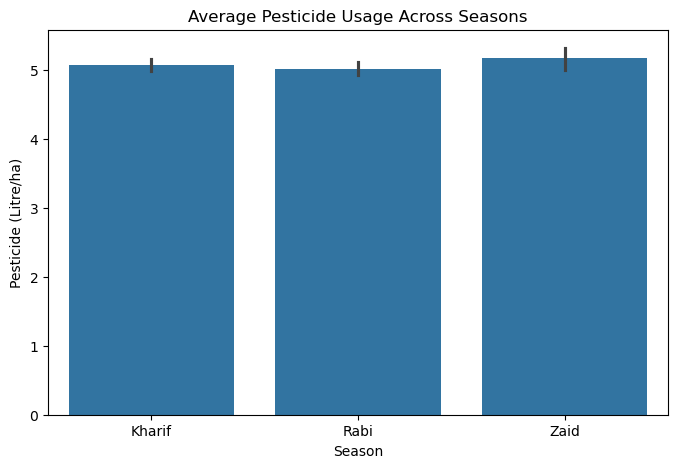

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Pesticide_Litre_ha")

plt.title("Average Pesticide Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Pesticide (Litre/ha)")

plt.show()

## 9. Water Usage and Efficiency

Water is an important resource in agriculture.

In this section, we examine how water usage and water efficiency
change across different seasons.

### Average Water Usage Across Seasons

Here, we calculate the average amount of water used by farms
in each season.

In [44]:
water = df.groupby("Season")["Water_Used_m3"].mean()

print(water)

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


### Water Usage Comparison

The graph compares the average water used across seasons.

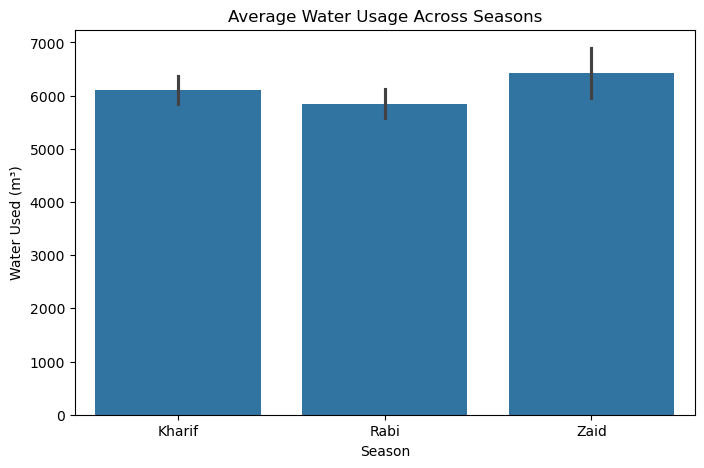

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="Season", y="Water_Used_m3")

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

### Average Water Efficiency Across Seasons

Water efficiency shows how much agricultural production is obtained
from the amount of water used.

Here, we compare water efficiency across different seasons.

In [46]:
water_efficiency = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean()

print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


### Water Efficiency Comparison

The graph shows the average water efficiency for each season.

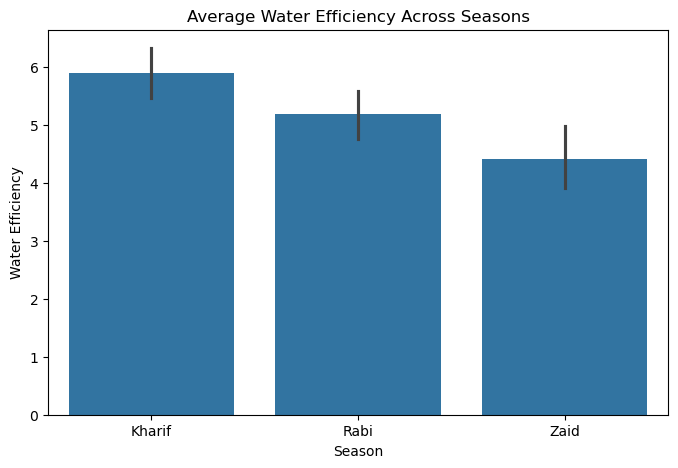

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Water_Efficiency_t_per_1000m3"
)

plt.title("Average Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency")

plt.show()

### Distribution of Irrigation Methods

Different farms may use different irrigation methods.
Here, we check which irrigation methods are present in the dataset
and how frequently they are used.

In [48]:
print(df["Irrigation_Method"].value_counts())

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


### Irrigation Method Graph

The graph shows the number of farms using each irrigation method.

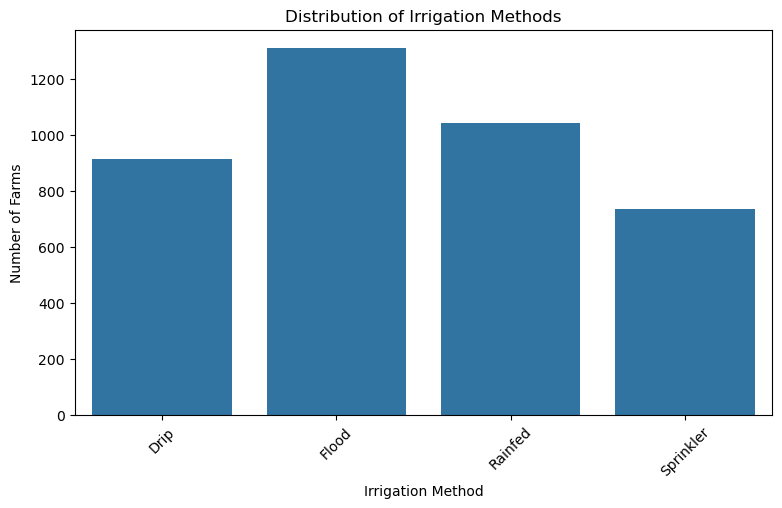

In [49]:
plt.figure(figsize=(9,5))

sns.countplot(data=df, x="Irrigation_Method")

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")

plt.xticks(rotation=45)

plt.show()

### Irrigation Methods Across Seasons

Here, we compare the use of different irrigation methods across seasons.
This helps us understand whether irrigation practices vary with seasons.

In [50]:
irrigation_season = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"]
)

print(irrigation_season)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif              405    590      463        321
Rabi                370    526      438        293
Zaid                140    194      140        120


### Irrigation Methods by Season

The graph compares the number of farms using different irrigation
methods in each season.

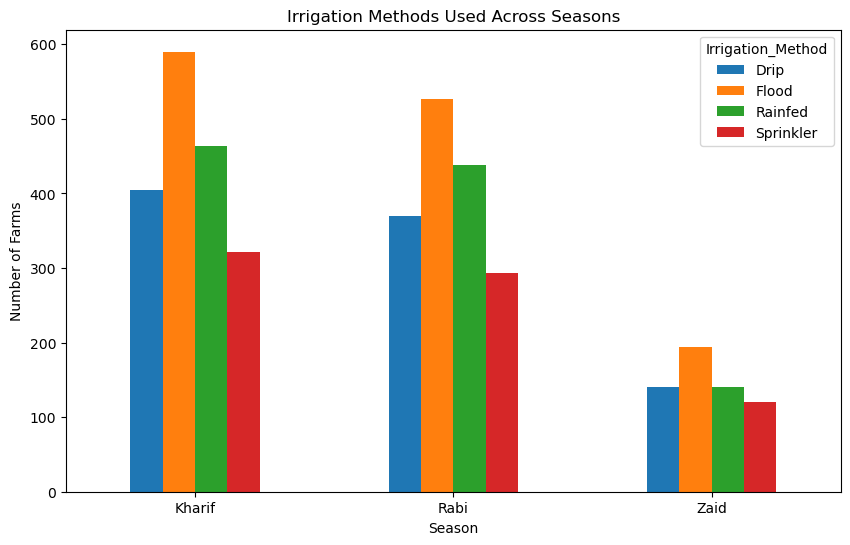

In [51]:
irrigation_season.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Irrigation Methods Used Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.xticks(rotation=0)

plt.show()

## 10. Agricultural Performance Analysis

Yield is one of the main measures of agricultural performance.

In this section, we compare yield, production and other performance
measures across different seasons.

In [52]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


### Yield Across Seasons

The graph compares the average agricultural yield across different seasons.

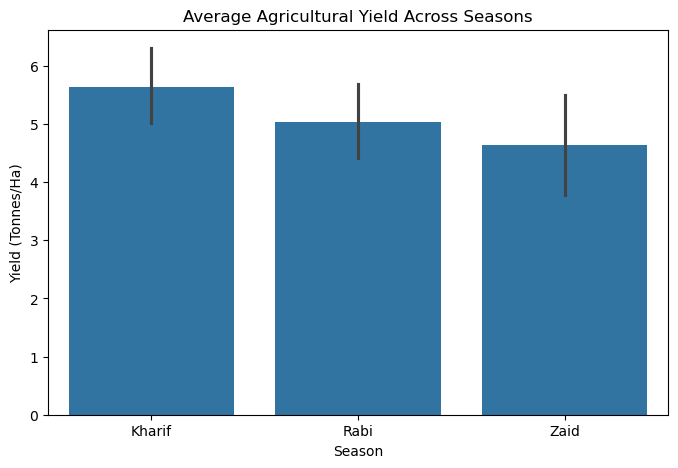

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Agricultural Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Yield Statistics by Season

The following table provides more details about yield in each season,
including the number of observations, mean, median, minimum, maximum
and standard deviation.

In [54]:
yield_summary = df.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

yield_summary

,count,mean,median,min,max,std
Season,,,,,,
Kharif,1779,5.628612,1.94,0.3,101.44,14.392742
Rabi,1627,5.039435,1.67,0.3,93.13,12.751545
Zaid,594,4.641313,1.46,0.3,64.76,11.273088


### Distribution of Yield Across Seasons

A boxplot is used to compare the distribution of yield between seasons.
It can also help us identify unusually high or low observations.

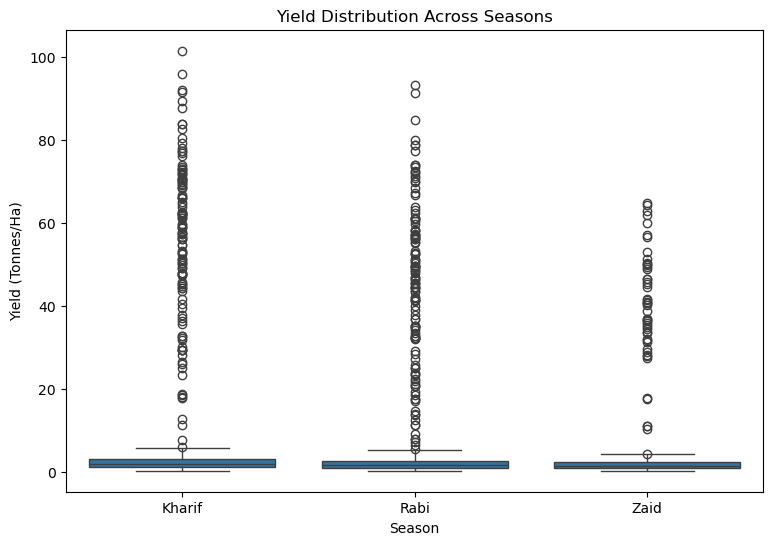

In [55]:
plt.figure(figsize=(9,6))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Highest and Lowest Yield Season

Here, we identify the season with the highest average yield and
the season with the lowest average yield.

In [56]:
best_season = season_yield.idxmax()
worst_season = season_yield.idxmin()

print("Highest average yield season:", best_season)
print("Lowest average yield season:", worst_season)

Highest average yield season: Kharif
Lowest average yield season: Zaid


### Average Production by Season

Production represents the total agricultural output.

Here, we compare the average production across different seasons.

In [57]:
production = df.groupby("Season")["Production_Tonnes"].mean()

print(production)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


### Production Across Seasons

The graph shows the average agricultural production for each season.

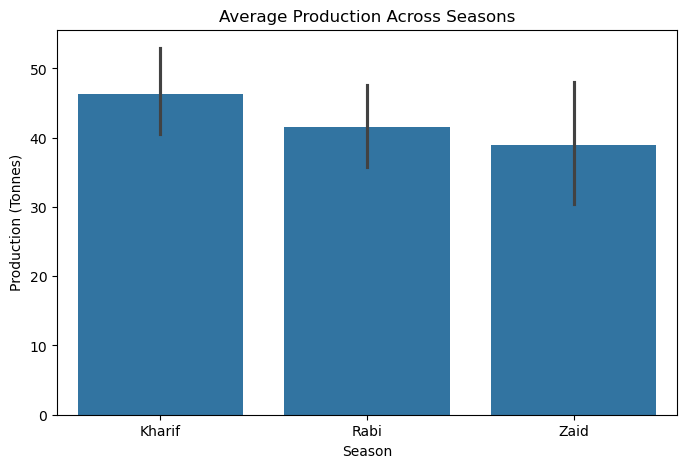

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Production_Tonnes"
)

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")

plt.show()

## 11. Crop-wise Analysis

Agricultural performance may also differ between crops.

In this section, we compare crop yields and study how crop performance
changes across different seasons.

In [59]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean()

print(crop_yield.sort_values(ascending=False))

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


### Crop Yield Comparison

The graph compares the average yield of the different crops
present in the dataset.

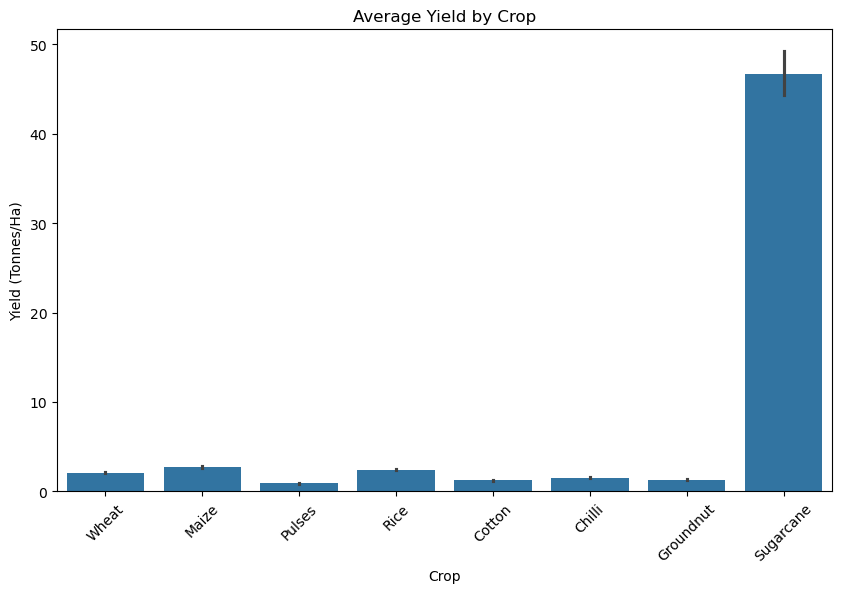

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.show()

### Crop Performance Across Seasons

Here, we calculate the average yield for each combination of
season and crop.

This helps us see whether a crop performs differently in different seasons.

In [61]:
crop_season = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().reset_index()

print(crop_season)

    Season       Crop  Yield_Tonnes_Ha
0   Kharif     Chilli         1.731459
1   Kharif     Cotton         1.374512
2   Kharif  Groundnut         1.484974
3   Kharif      Maize         2.966410
4   Kharif     Pulses         1.036063
5   Kharif       Rice         2.698376
6   Kharif  Sugarcane        53.459120
7   Kharif      Wheat         2.253664
8     Rabi     Chilli         1.465031
9     Rabi     Cotton         1.198358
10    Rabi  Groundnut         1.233164
11    Rabi      Maize         2.603648
12    Rabi     Pulses         0.875962
13    Rabi       Rice         2.322847
14    Rabi  Sugarcane        43.286124
15    Rabi      Wheat         2.057468
16    Zaid     Chilli         1.195312
17    Zaid     Cotton         0.960217
18    Zaid  Groundnut         1.037778
19    Zaid      Maize         2.290952
20    Zaid     Pulses         0.669677
21    Zaid       Rice         1.900490
22    Zaid  Sugarcane        38.423922
23    Zaid      Wheat         1.748588


### Crop Yield Across Seasons

The following graph compares the yield of different crops
across the available seasons.

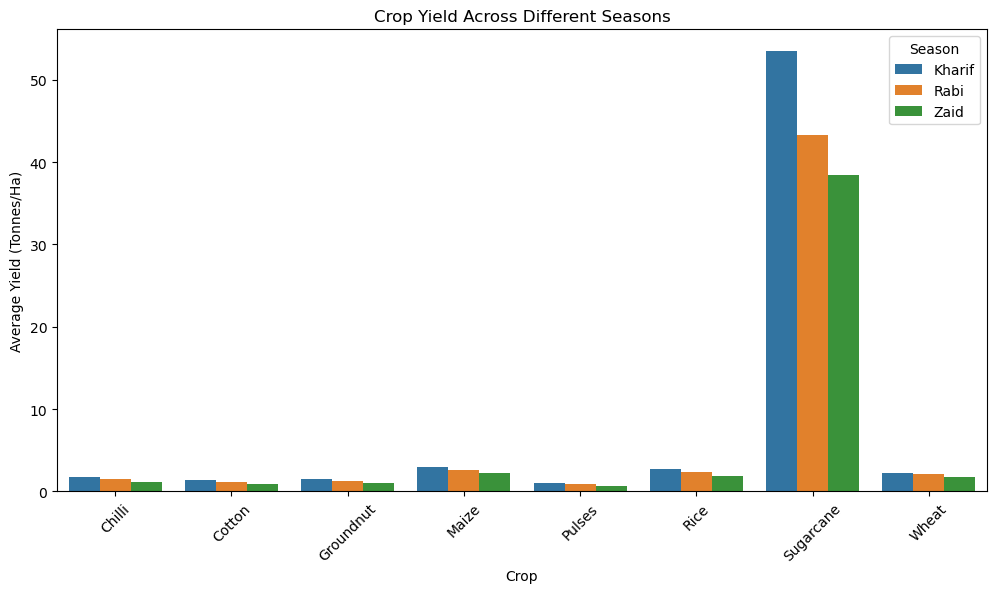

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=crop_season,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Crop Yield Across Different Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.show()

In [63]:
for season in df["Season"].unique():

    data = crop_season[crop_season["Season"] == season]

    best_crop = data.loc[
        data["Yield_Tonnes_Ha"].idxmax()
    ]

    print(
        season,
        "->",
        best_crop["Crop"],
        "with average yield:",
        round(best_crop["Yield_Tonnes_Ha"], 2)
    )

Kharif -> Sugarcane with average yield: 53.46
Rabi -> Sugarcane with average yield: 43.29
Zaid -> Sugarcane with average yield: 38.42


### Average Yield by State

Here, we calculate the average agricultural yield for each state.

In [64]:
state_yield = df.groupby("State")["Yield_Tonnes_Ha"].mean()

print(state_yield.sort_values(ascending=False))

State
Punjab            6.121116
Karnataka         5.685481
Gujarat           5.659016
Telangana         5.044477
Maharashtra       5.017480
Madhya Pradesh    4.989940
Tamil Nadu        4.875175
Andhra Pradesh    4.628771
Name: Yield_Tonnes_Ha, dtype: float64


### State-wise Yield Comparison

The graph shows the average agricultural yield for different states.

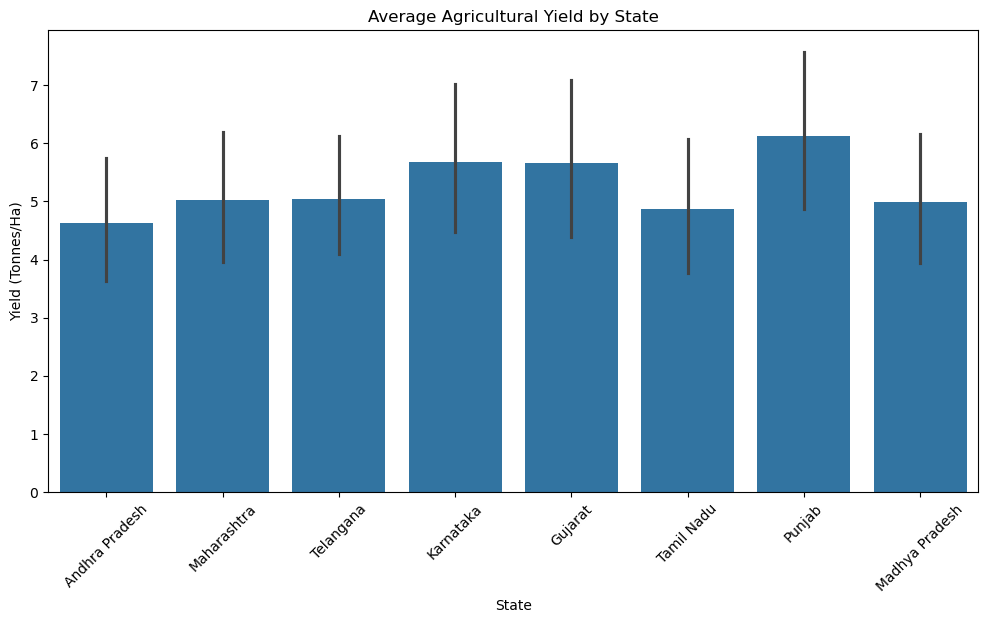

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="State",
    y="Yield_Tonnes_Ha"
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.show()

### Yield by State and Season

Here, we compare average yield using both state and season.

This helps us understand whether seasonal performance is different
in different geographical areas.

In [66]:
state_season = df.groupby(
    ["State", "Season"]
)["Yield_Tonnes_Ha"].mean().reset_index()

print(state_season)

             State  Season  Yield_Tonnes_Ha
0   Andhra Pradesh  Kharif         5.676958
1   Andhra Pradesh    Rabi         3.470931
2   Andhra Pradesh    Zaid         4.448000
3          Gujarat  Kharif         6.338416
4          Gujarat    Rabi         5.441700
5          Gujarat    Zaid         4.066716
6        Karnataka  Kharif         6.455024
7        Karnataka    Rabi         4.567864
8        Karnataka    Zaid         6.623243
9   Madhya Pradesh  Kharif         5.985265
10  Madhya Pradesh    Rabi         3.760385
11  Madhya Pradesh    Zaid         5.478889
12     Maharashtra  Kharif         5.430315
13     Maharashtra    Rabi         5.501927
14     Maharashtra    Zaid         2.277778
15          Punjab  Kharif         4.100633
16          Punjab    Rabi         8.609355
17          Punjab    Zaid         5.909610
18      Tamil Nadu  Kharif         5.520534
19      Tamil Nadu    Rabi         4.501394
20      Tamil Nadu    Zaid         4.097746
21       Telangana  Kharif      

### State-wise Seasonal Yield

The graph compares agricultural yield across states and seasons.

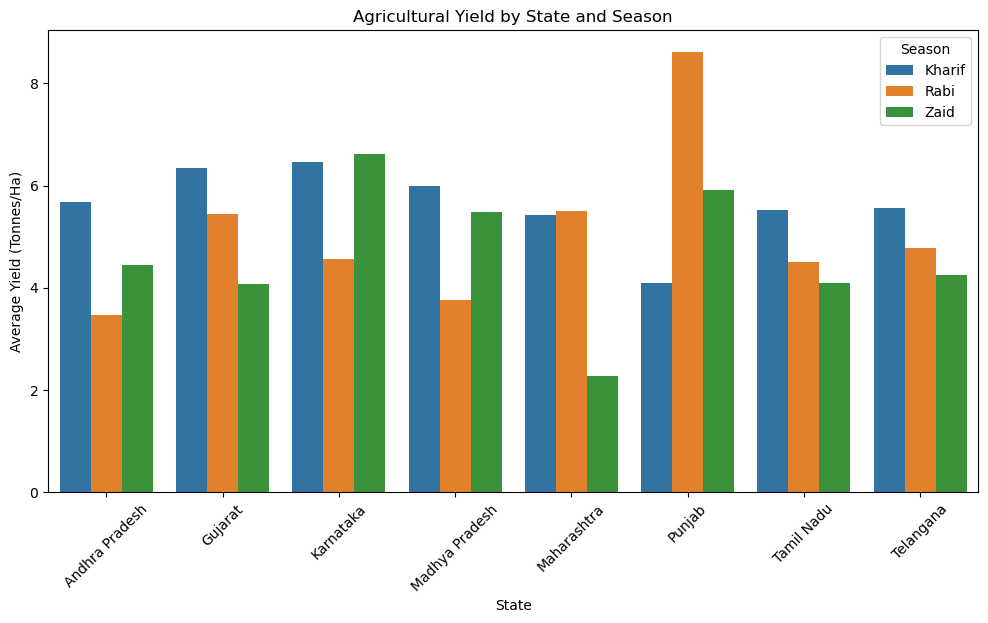

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_season,
    x="State",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Agricultural Yield by State and Season")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)

plt.show()

## 13. Economic Performance Analysis

Agricultural performance is not only related to production and yield.
The economic side is also important.

Here, we compare cost, revenue and profit across different seasons.

### Average Cost by Season

Here, we compare the average total cost of agricultural activities
across different seasons.

In [68]:
cost = df.groupby("Season")["Total_Cost_INR"].mean()

print(cost)

Season
Kharif    531804.408094
Rabi      513836.578365
Zaid      543976.728956
Name: Total_Cost_INR, dtype: float64


### Average Revenue by Season

Revenue represents the income generated from agricultural production.

Here, we compare the average revenue across seasons.

In [69]:
revenue = df.groupby("Season")["Revenue_INR"].mean()

print(revenue)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


### Average Profit by Season

Profit is calculated from the economic performance recorded in the dataset.

Here, we compare the average profit across different seasons.

In [70]:
profit = df.groupby("Season")["Profit_INR"].mean()

print(profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


### Profit Comparison Across Seasons

The graph compares the average profit generated in each season.

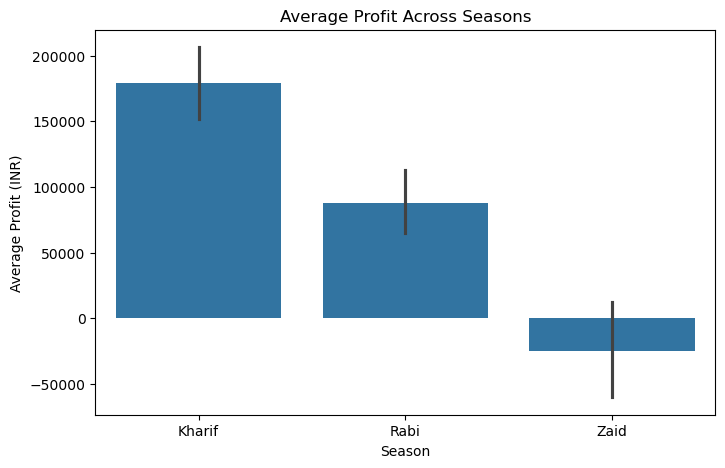

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR"
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.show()

### Cost, Revenue and Profit Comparison

Here, cost, revenue and profit are compared together for each season.
This gives a simple overview of the economic performance of agriculture
in different seasons.

In [72]:
money = df.groupby("Season")[
    ["Total_Cost_INR", "Revenue_INR", "Profit_INR"]
].mean()

print(money)

        Total_Cost_INR    Revenue_INR     Profit_INR
Season                                              
Kharif   531804.408094  710719.055649  178914.647555
Rabi     513836.578365  601526.048556   87689.470191
Zaid     543976.728956  519171.904040  -24804.824916


### Economic Performance Graph

The graph compares average cost, revenue and profit across seasons.

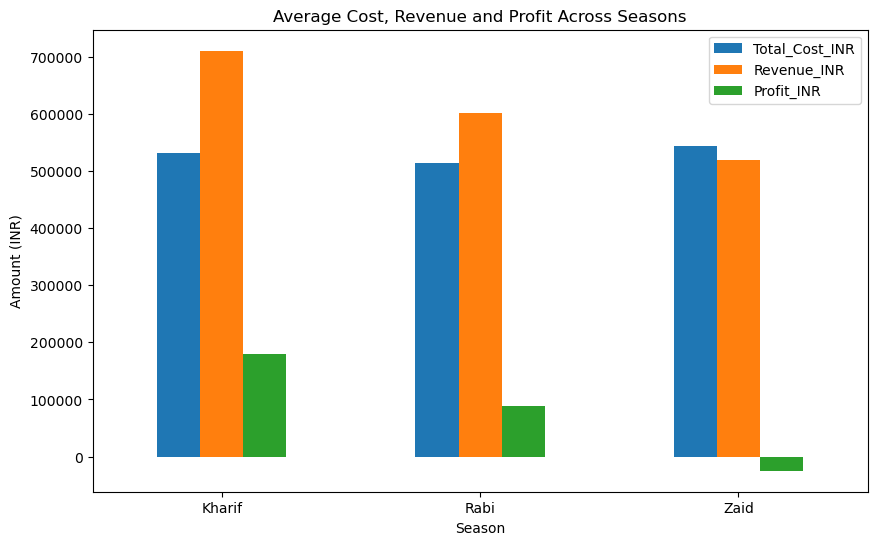

In [73]:
money.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Cost, Revenue and Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")

plt.xticks(rotation=0)

plt.show()

## 14. Seed Quality Analysis

Seed quality can be an important factor in crop performance.

Here, we compare the average seed quality score across seasons.

In [74]:
seed_quality = df.groupby("Season")["Seed_Quality_Score"].mean()

print(seed_quality)

Season
Kharif    0.821613
Rabi      0.832170
Zaid      0.823165
Name: Seed_Quality_Score, dtype: float64


### Seed Quality Across Seasons

The graph shows the average seed quality score for each season.

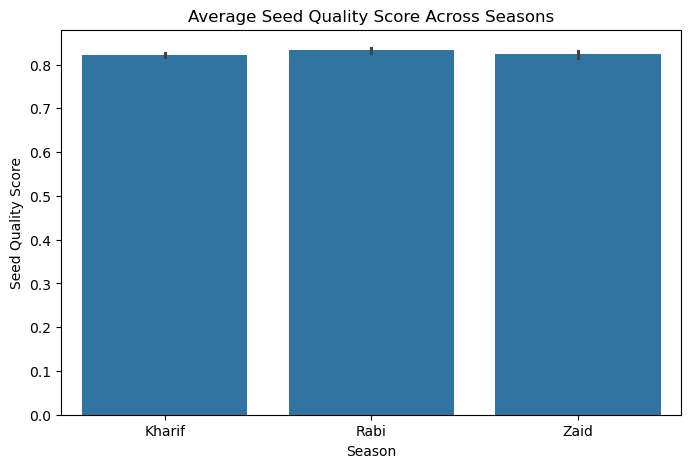

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Seed_Quality_Score"
)

plt.title("Average Seed Quality Score Across Seasons")
plt.xlabel("Season")
plt.ylabel("Seed Quality Score")

plt.show()

### Relationship Between Seed Quality and Yield

A scatter plot is used to see whether there is any visible relationship
between seed quality and agricultural yield.

The seasons are shown separately to make comparison easier.

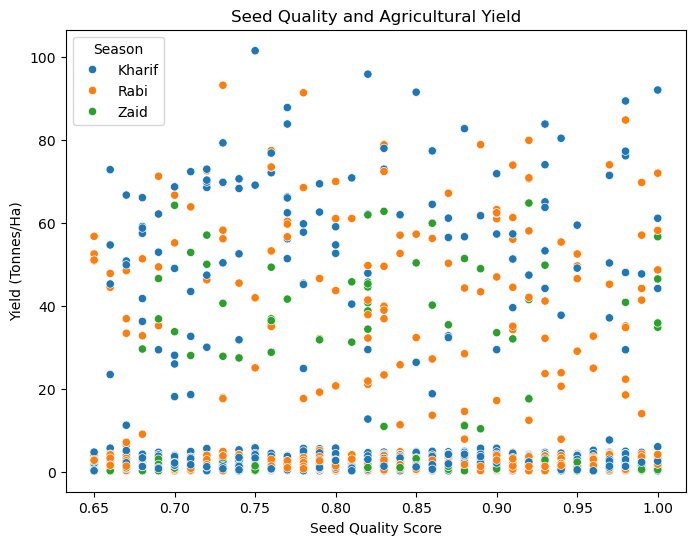

In [76]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Seed Quality and Agricultural Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

## 15. Disease and Pest Risk Analysis

Disease and pest risk can affect agricultural production.

Here, we compare the average disease and pest risk across different seasons.

In [77]:
risk = df.groupby("Season")["Disease_Pest_Risk_pct"].mean()

print(risk)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


### Disease and Pest Risk Across Seasons

The graph shows the average disease and pest risk percentage
for each season.

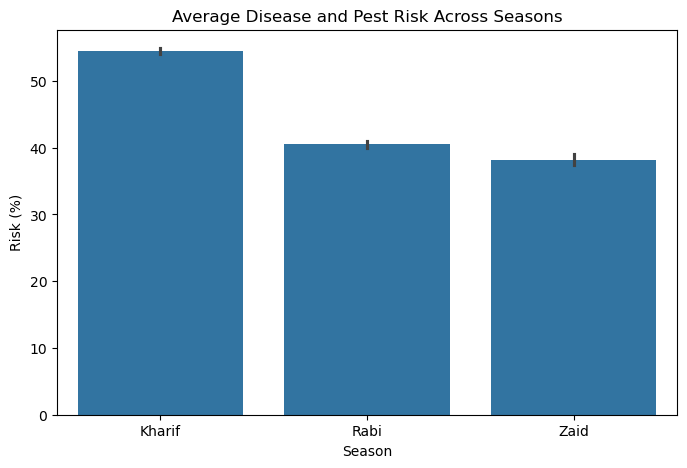

In [78]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Season",
    y="Disease_Pest_Risk_pct"
)

plt.title("Average Disease and Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.show()

### Pesticide Usage and Disease/Pest Risk

Here, we compare average pesticide usage and disease or pest risk
across seasons.

This comparison can help us observe whether seasons with higher
risk also show differences in pesticide usage.

In [79]:
risk_pesticide = df.groupby("Season")[
    ["Pesticide_Litre_ha", "Disease_Pest_Risk_pct"]
].mean()

print(risk_pesticide)

        Pesticide_Litre_ha  Disease_Pest_Risk_pct
Season                                           
Kharif            5.079747              54.467903
Rabi              5.024690              40.482114
Zaid              5.171212              38.216667


In [80]:
numeric_data = df.select_dtypes(include=["int64", "float64"])

print(numeric_data.columns)

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')


## 16. Correlation Analysis

Correlation is used to study the relationship between numerical variables.

It helps us understand whether two variables tend to increase or decrease
together.

Correlation does not necessarily mean that one variable causes another.

In [81]:
correlation = numeric_data.corr()

print(correlation)

                               Farm_Area_Hectares  Rainfall_mm  \
Farm_Area_Hectares                       1.000000     0.007256   
Rainfall_mm                              0.007256     1.000000   
Avg_Temperature_C                        0.036870     0.198492   
Humidity_pct                             0.000471     0.521069   
Sunlight_Hours_Day                       0.001821    -0.362779   
Soil_pH                                  0.009857     0.016657   
Soil_Moisture_pct                        0.004033     0.508941   
Nitrogen_kg_ha                           0.013658     0.007460   
Phosphorus_kg_ha                        -0.006625     0.020940   
Potassium_kg_ha                          0.000195     0.031373   
Fertilizer_kg_ha                         0.014975     0.024602   
Pesticide_Litre_ha                      -0.005207     0.004058   
Seed_Quality_Score                       0.015236    -0.018581   
Yield_Tonnes_Ha                          0.030203     0.030951   
Production

### Correlation Heatmap

The heatmap provides a visual representation of the correlations
between the numerical variables.

Values closer to 1 indicate a strong positive relationship,
while values closer to -1 indicate a strong negative relationship.

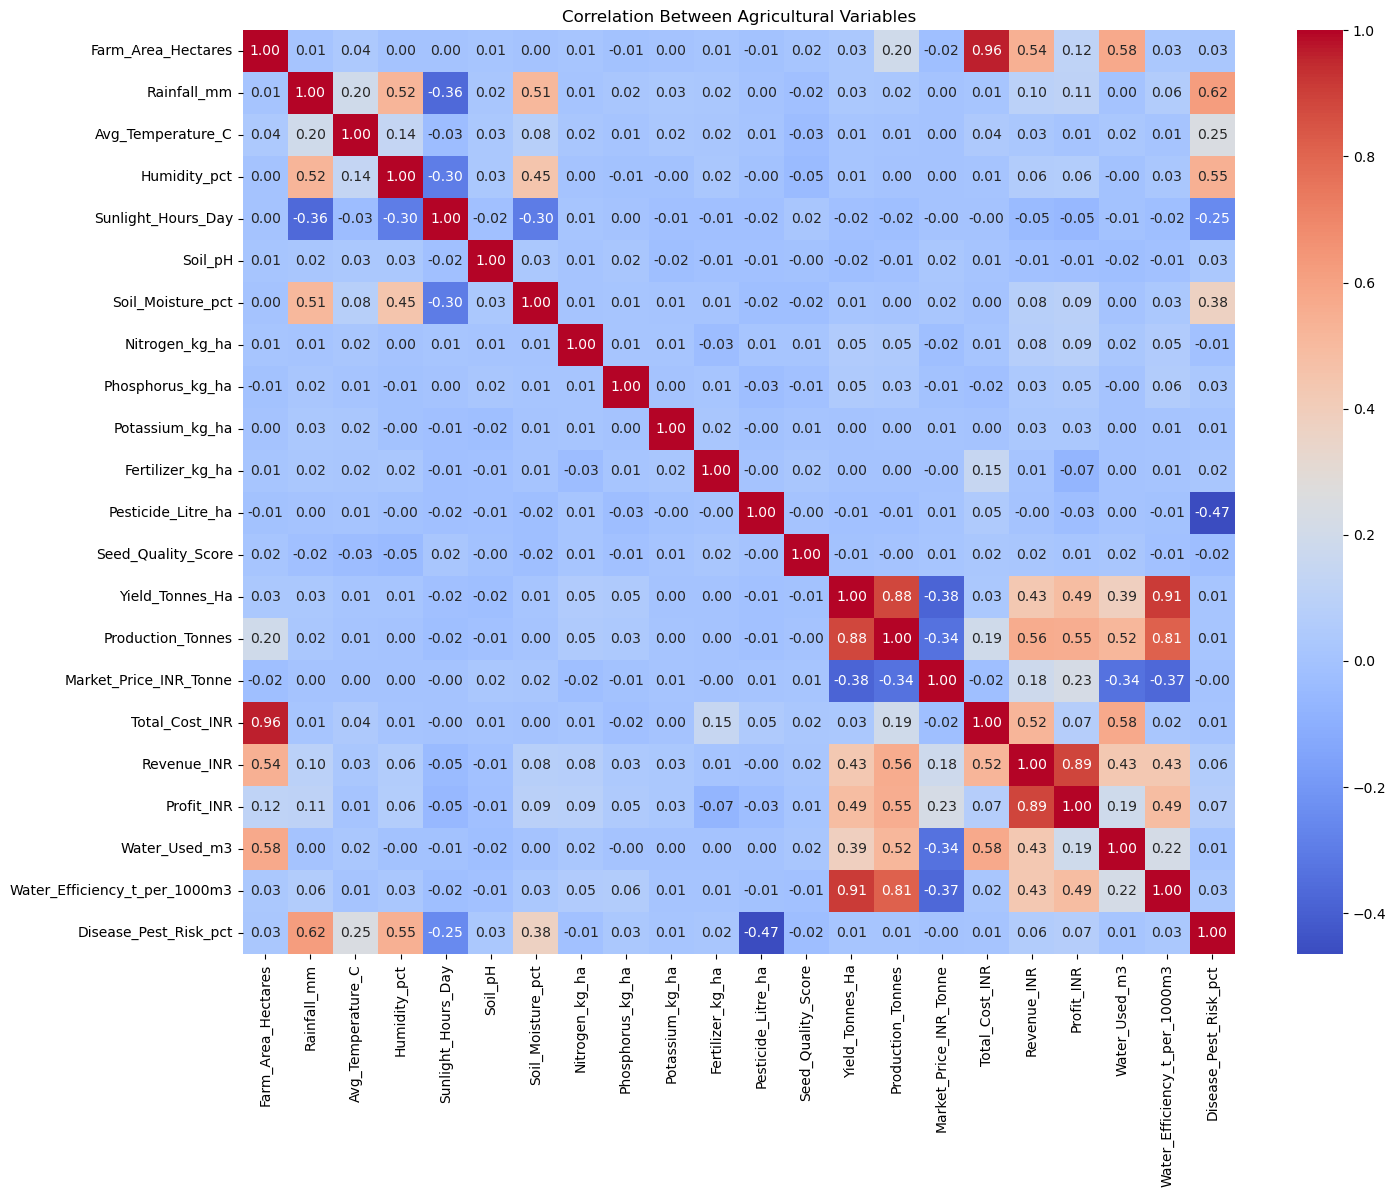

In [82]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Agricultural Variables")

plt.show()

### Correlation with Agricultural Yield

Since yield is the main performance measure in this project,
we look specifically at how other numerical variables are related
to yield.

In [83]:
yield_correlation = correlation[
    "Yield_Tonnes_Ha"
].sort_values(ascending=False)

print(yield_correlation)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


### Rainfall and Yield

The scatter plot is used to observe the relationship between
rainfall and agricultural yield.

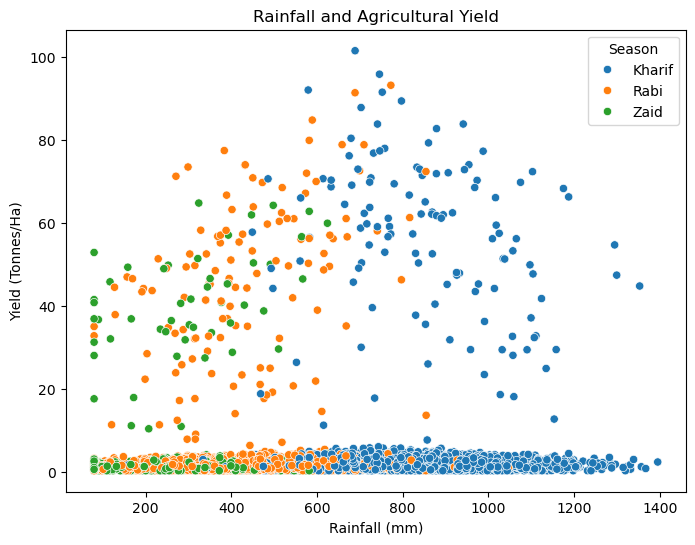

In [84]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Rainfall and Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Temperature and Yield

The scatter plot shows the relationship between average temperature
and agricultural yield.

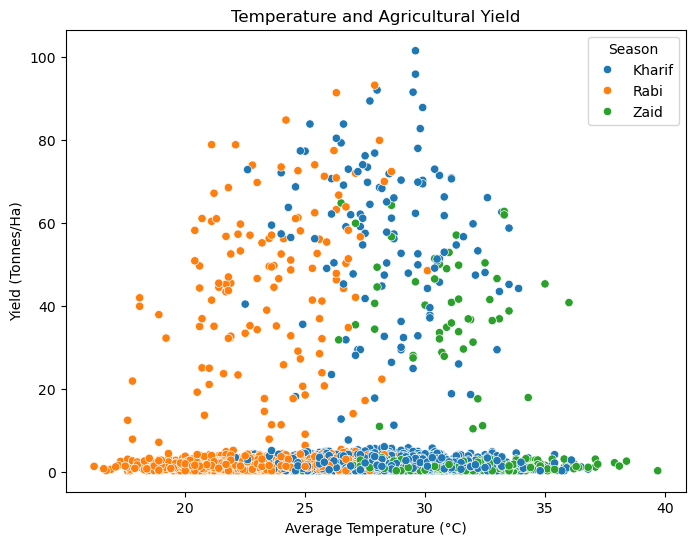

In [85]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Temperature and Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Soil Moisture and Yield

Here, we examine the relationship between soil moisture and
agricultural yield.

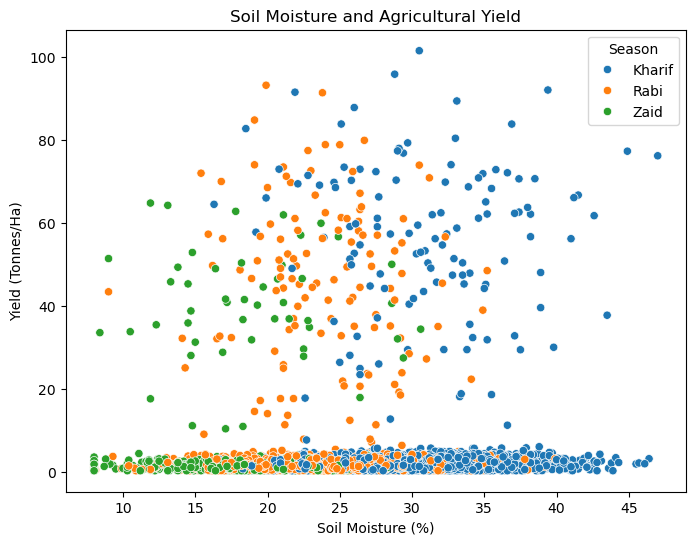

In [86]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Soil Moisture and Agricultural Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Fertilizer Usage and Yield

Here, we examine whether there is a visible relationship between
fertilizer usage and agricultural yield.

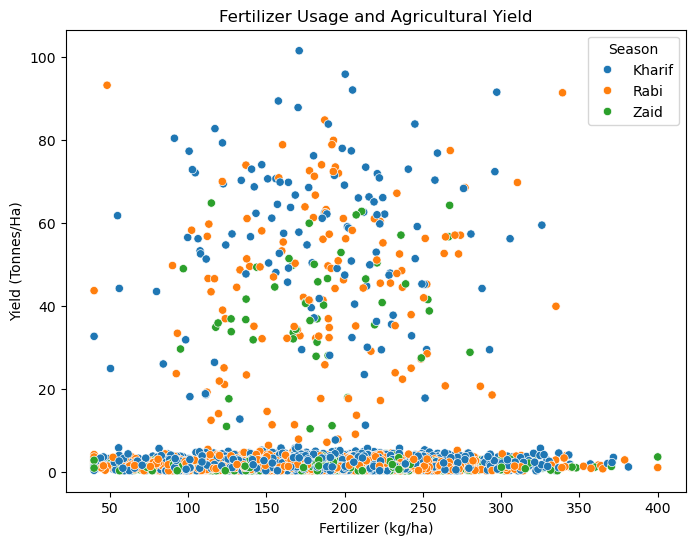

In [87]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Fertilizer Usage and Agricultural Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Water Usage and Yield

The scatter plot is used to observe the relationship between
water used and agricultural yield.

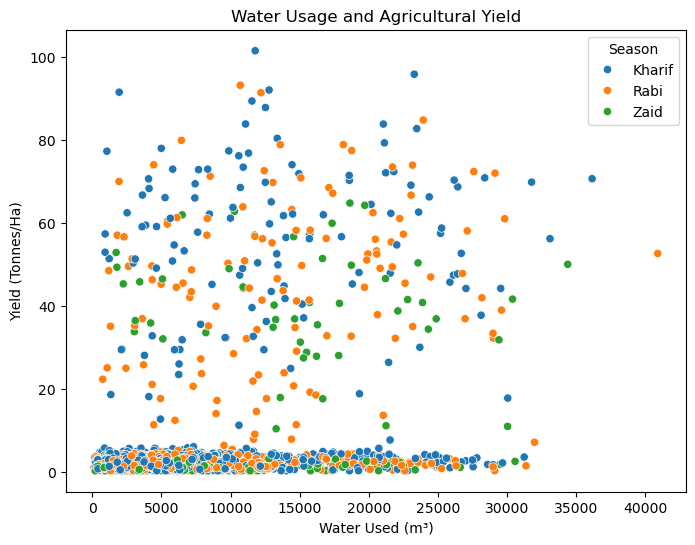

In [88]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Water Usage and Agricultural Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

### Seasonal Performance Summary

The following table provides the average values of the main variables
for each season.

This table makes it easier to compare the overall performance of
different seasons.

In [89]:
final_summary = df.groupby("Season").agg({
    "Farm_Area_Hectares": "mean",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean",
    "Nitrogen_kg_ha": "mean",
    "Phosphorus_kg_ha": "mean",
    "Potassium_kg_ha": "mean",
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean",
    "Seed_Quality_Score": "mean",
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Market_Price_INR_Tonne": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
})

final_summary = final_summary.round(2)

final_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,849.20,28.45,71.81,6.79,31.15,120.02,58.10,105.30,187.08,...,0.82,5.63,46.31,44850.91,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,437.62,23.49,57.89,7.59,24.07,120.40,57.31,103.93,185.41,...,0.83,5.04,41.49,44747.97,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,304.65,31.04,52.01,8.18,19.28,120.53,58.13,105.42,184.64,...,0.82,4.64,38.89,44212.03,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


In [90]:
final_summary = final_summary.sort_values(
    by="Yield_Tonnes_Ha",
    ascending=False
)

final_summary

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,
Kharif,7.94,849.20,28.45,71.81,6.79,31.15,120.02,58.10,105.30,187.08,...,0.82,5.63,46.31,44850.91,531804.41,710719.06,178914.65,6102.20,5.89,54.47
Rabi,7.75,437.62,23.49,57.89,7.59,24.07,120.40,57.31,103.93,185.41,...,0.83,5.04,41.49,44747.97,513836.58,601526.05,87689.47,5846.99,5.19,40.48
Zaid,8.09,304.65,31.04,52.01,8.18,19.28,120.53,58.13,105.42,184.64,...,0.82,4.64,38.89,44212.03,543976.73,519171.90,-24804.82,6419.89,4.41,38.22


In [91]:
best_yield_season = df.groupby(
    "Season"
)["Yield_Tonnes_Ha"].mean().idxmax()

lowest_yield_season = df.groupby(
    "Season"
)["Yield_Tonnes_Ha"].mean().idxmin()

best_profit_season = df.groupby(
    "Season"
)["Profit_INR"].mean().idxmax()

highest_rainfall_season = df.groupby(
    "Season"
)["Rainfall_mm"].mean().idxmax()

highest_water_efficiency_season = df.groupby(
    "Season"
)["Water_Efficiency_t_per_1000m3"].mean().idxmax()

highest_risk_season = df.groupby(
    "Season"
)["Disease_Pest_Risk_pct"].mean().idxmax()

print("Highest yield season:", best_yield_season)
print("Lowest yield season:", lowest_yield_season)
print("Highest profit season:", best_profit_season)
print("Highest rainfall season:", highest_rainfall_season)
print("Highest water efficiency season:", highest_water_efficiency_season)
print("Highest disease/pest risk season:", highest_risk_season)

Highest yield season: Kharif
Lowest yield season: Zaid
Highest profit season: Kharif
Highest rainfall season: Kharif
Highest water efficiency season: Kharif
Highest disease/pest risk season: Kharif


### Ranking Seasons by Yield

The seasons are arranged according to their average agricultural yield,
from highest to lowest.

In [92]:
print("Average Yield by Season:")
print(
    df.groupby("Season")[
        "Yield_Tonnes_Ha"
    ].mean().round(2)
)

print("\nAverage Production by Season:")
print(
    df.groupby("Season")[
        "Production_Tonnes"
    ].mean().round(2)
)

print("\nAverage Profit by Season:")
print(
    df.groupby("Season")[
        "Profit_INR"
    ].mean().round(2)
)

print("\nAverage Rainfall by Season:")
print(
    df.groupby("Season")[
        "Rainfall_mm"
    ].mean().round(2)
)

print("\nAverage Water Efficiency by Season:")
print(
    df.groupby("Season")[
        "Water_Efficiency_t_per_1000m3"
    ].mean().round(2)
)

print("\nAverage Disease/Pest Risk by Season:")
print(
    df.groupby("Season")[
        "Disease_Pest_Risk_pct"
    ].mean().round(2)
)

Average Yield by Season:
Season
Kharif    5.63
Rabi      5.04
Zaid      4.64
Name: Yield_Tonnes_Ha, dtype: float64

Average Production by Season:
Season
Kharif    46.31
Rabi      41.49
Zaid      38.89
Name: Production_Tonnes, dtype: float64

Average Profit by Season:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64

Average Rainfall by Season:
Season
Kharif    849.20
Rabi      437.62
Zaid      304.65
Name: Rainfall_mm, dtype: float64

Average Water Efficiency by Season:
Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64

Average Disease/Pest Risk by Season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


## 21. Saving the Results

After completing the analysis, the cleaned dataset is saved as a new CSV file.

This keeps the original dataset unchanged and provides a cleaned version
that can be used later.

In [93]:
df.to_csv(
    "cleaned_agriculture_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


### Saving Seasonal Performance Summary

The final seasonal comparison table is also saved as a CSV file
so that the results can be used outside the notebook if required.

In [94]:
final_summary.to_csv(
    "seasonal_performance_summary.csv"
)

print("Seasonal summary saved successfully")

Seasonal summary saved successfully


In [95]:
import os

print(os.getcwd())

C:\Users\SHREE SINHA


## Recommendations

1. Seasonal differences should be considered while planning
   agricultural activities.

2. Crops that perform better in particular seasons can be
   considered for seasonal crop planning.

3. Water usage should be monitored, especially in seasons
   where water consumption is high.

4. Irrigation methods can be selected according to rainfall
   and soil moisture conditions.

5. Fertilizer and pesticide usage should be monitored to
   maintain efficient resource usage.

6. Seasons with higher disease and pest risk may require
   additional monitoring.

7. Further analysis can be performed on factors that show
   strong relationships with agricultural yield.

## Conclusion

This project analyzed agricultural data from different seasons
to understand variations in agricultural performance.

The analysis covered environmental conditions, soil conditions,
nutrient usage, irrigation, fertilizer and pesticide usage,
crop performance, yield, production, water efficiency,
economic performance and disease/pest risk.

Different data analysis and visualization techniques were used
to compare seasons and identify patterns and relationships.

The results provide useful insights into seasonal variations
in agricultural performance and can help in making
data-driven agricultural planning decisions.